# TensorFlow Course 1 Week 3 - Complete CNN Practice Notebook

## Introduction to Convolutional Neural Networks

This comprehensive notebook covers all concepts from Week 3 of the TensorFlow specialization, focusing on Convolutional Neural Networks (CNNs) for computer vision. We'll enhance our Fashion MNIST classifier using convolutions and pooling, and explore how these operations work at a fundamental level.


In [16]:
%pip install pooch

  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
Using cached pooch-1.8.2-py3-none-any.whl (64 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import all necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.datasets import ascent

## 1. Understanding the Problem with Traditional Neural Networks

Before diving into CNNs, let's understand why traditional Dense Neural Networks are **naive** for image processing. The key issue is that they treat images as flat arrays, completely ignoring spatial relationships between pixels.

### Traditional DNN Limitations

Traditional DNNs process images by **flattening** them immediately, which destroys spatial information. For a 28×28 Fashion MNIST image:

$$\text{Input} = [p_1, p_2, p_3, ..., p_{784}]$$

Where each $p_i$ represents a pixel value, but the network has **no understanding** that $p_1$ and $p_2$ might be spatially adjacent.


In [2]:
# Load Fashion MNIST dataset
fmnist = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()

# Normalize pixel values to [0,1] range
training_images = training_images / 255.0
test_images = test_images / 255.0

print(f"Training data shape: {training_images.shape}")
print(f"Test data shape: {test_images.shape}")
print(f"Number of classes: {len(np.unique(training_labels))}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Number of classes: 10


## 2. Mathematical Foundation of Convolutions

### What is a Convolution?

A convolution is a mathematical operation where we apply a **filter** (kernel) across an image to detect specific features:

$$\text{Feature Response} = \sum_{i,j} \text{Filter}[i,j] \times \text{Image}[x+i, y+j]$$

### Edge Detection Example

Let's see how a simple edge detection filter works:


In [ ]:
# Vertical Edge Detection Filter
vertical_filter = np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]], 
                            dtype=np.float32
                            )

# Example image patch
image_patch = np.array([[100, 100, 0],
                        [100, 100, 0],
                        [100, 100, 0]], 
                        dtype=np.float32
                    )

# Manual convolution calculation
response = np.sum(image_patch * vertical_filter)
print(f"Convolution response: {response}")
print("Strong negative response indicates a vertical edge (bright to dark)")

Convolution response: -300.0
Strong negative response indicates a vertical edge (bright to dark)


### Visualizing Different Filter Types


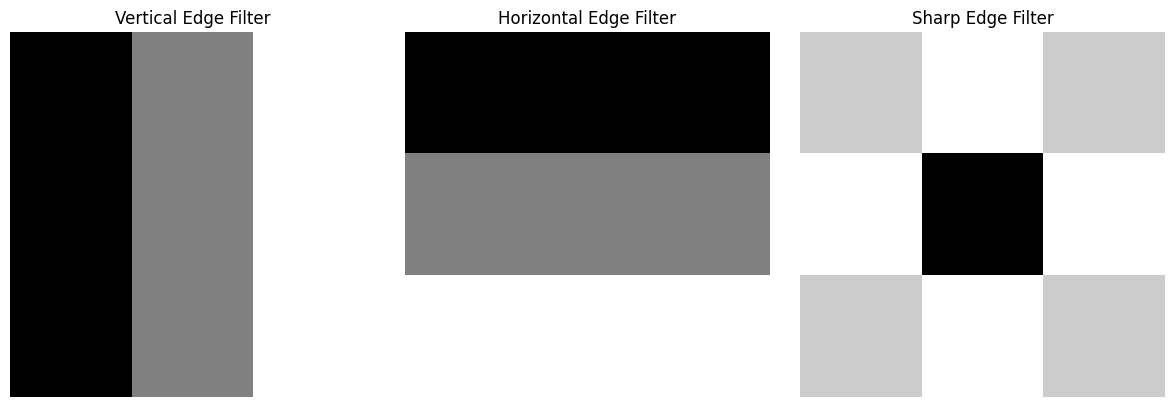

In [4]:
# Define different types of filters
filters = {
    'Vertical Edge': np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]),
    'Horizontal Edge': np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]),
    'Sharp Edge': np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
}

# Visualize filters
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (name, filt) in enumerate(filters.items()):
    axes[i].imshow(filt, cmap='gray')
    axes[i].set_title(f'{name} Filter')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 3. Understanding Pooling Operations

### Max Pooling Mathematics

Max pooling reduces spatial dimensions while preserving the strongest features:

$$\text{MaxPool}(R) = \max_{(i,j) \in R} x_{i,j}$$

For a 2×2 pooling window, we select the maximum value from each region.


In [5]:
# Demonstrate max pooling on a simple example
input_matrix = np.array([[1, 3, 2, 4],
                        [5, 6, 1, 2],
                        [2, 8, 4, 3],
                        [1, 0, 7, 9]])

print("Original 4×4 matrix:")
print(input_matrix)

# Manual 2×2 max pooling
pooled_result = np.zeros((2, 2))
for i in range(0, 4, 2):
    for j in range(0, 4, 2):
        # Extract 2×2 window
        window = input_matrix[i:i+2, j:j+2]
        # Take maximum
        pooled_result[i//2, j//2] = np.max(window)

print("\nAfter 2×2 Max Pooling:")
print(pooled_result)

Original 4×4 matrix:
[[1 3 2 4]
 [5 6 1 2]
 [2 8 4 3]
 [1 0 7 9]]

After 2×2 Max Pooling:
[[6. 4.]
 [8. 9.]]


## 4. Building Your First CNN - Architecture Design

### Traditional DNN vs CNN Comparison


In [10]:
# Traditional Dense Neural Network (from Week 2)
traditional_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Flatten(),                    # 28×28 → 784
    tf.keras.layers.Dense(128, activation='relu'), # 784 → 128
    tf.keras.layers.Dense(10, activation='softmax') # 128 → 10
])

print("=== Traditional DNN Architecture ===")
traditional_model.summary()

=== Traditional DNN Architecture ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Enhanced CNN Architecture


In [12]:
# Convolutional Neural Network
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # First convolutional block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # 28×28×1 → 26×26×64
    tf.keras.layers.MaxPooling2D(2, 2),                     # 26×26×64 → 13×13×64

    # Second convolutional block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # 13×13×64 → 11×11×64
    tf.keras.layers.MaxPooling2D(2, 2),                     # 11×11×64 → 5×5×64

    # Classification head
    tf.keras.layers.Flatten(),                              # 5×5×64 → 1600
    tf.keras.layers.Dense(128, activation='relu'),          # 1600 → 128
    tf.keras.layers.Dense(10, activation='softmax')         # 128 → 10
])

print("\n=== CNN Architecture ===")
cnn_model.summary()


=== CNN Architecture ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,786 (952.29 KB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Understanding Shape Transformations

### Detailed Shape Analysis Through the Network

The CNN processes data through multiple transformations. Let's trace the exact shape changes:


In [8]:
# Create a sample input to trace shapes
sample_input = np.random.random((1, 28, 28, 1))

print("Shape transformations through CNN:")
print(f"Input shape: {sample_input.shape}")

# Simulate each layer transformation
x = sample_input
layer_names = ['Input', 'Conv2D_1', 'MaxPool_1', 'Conv2D_2', 'MaxPool_2', 'Flatten', 'Dense_1', 'Dense_2']
layer_shapes = [x.shape]

# First Conv2D: 28×28×1 → 26×26×64 (valid padding loses 2 pixels per dimension)
x = np.random.random((1, 26, 26, 64))
layer_shapes.append(x.shape)

# First MaxPool: 26×26×64 → 13×13×64 (halving spatial dimensions)
x = np.random.random((1, 13, 13, 64))
layer_shapes.append(x.shape)

# Second Conv2D: 13×13×64 → 11×11×64
x = np.random.random((1, 11, 11, 64))
layer_shapes.append(x.shape)

# Second MaxPool: 11×11×64 → 5×5×64
x = np.random.random((1, 5, 5, 64))
layer_shapes.append(x.shape)

# Flatten: 5×5×64 → 1600
x = np.random.random((1, 1600))
layer_shapes.append(x.shape)

# Dense layers
x = np.random.random((1, 128))
layer_shapes.append(x.shape)
x = np.random.random((1, 10))
layer_shapes.append(x.shape)

# Display transformation table
for name, shape in zip(layer_names, layer_shapes):
    if len(shape) == 4:  # 4D tensor (batch, height, width, channels)
        pixels = shape[1] * shape[2] * shape[3] if len(shape) > 1 else shape[1]
        print(f"{name:12} → {str(shape):20} | Total elements: {pixels:,}")
    else:  # 2D tensor (batch, features)
        print(f"{name:12} → {str(shape):20} | Total elements: {shape[1]:,}")

Shape transformations through CNN:
Input shape: (1, 28, 28, 1)
Input        → (1, 28, 28, 1)       | Total elements: 784
Conv2D_1     → (1, 26, 26, 64)      | Total elements: 43,264
MaxPool_1    → (1, 13, 13, 64)      | Total elements: 10,816
Conv2D_2     → (1, 11, 11, 64)      | Total elements: 7,744
MaxPool_2    → (1, 5, 5, 64)        | Total elements: 1,600
Flatten      → (1, 1600)            | Total elements: 1,600
Dense_1      → (1, 128)             | Total elements: 128
Dense_2      → (1, 10)              | Total elements: 10


## 6. Training and Performance Comparison

### Training the Traditional DNN


In [9]:
# Compile and train traditional model
traditional_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== Training Traditional DNN ===")
traditional_history = traditional_model.fit(
    training_images, training_labels,
    epochs=5,
    verbose=1
)

# Evaluate traditional model
traditional_test_loss, traditional_test_accuracy = traditional_model.evaluate(
    test_images, test_labels, verbose=0
)
print(f"Traditional DNN - Test Accuracy: {traditional_test_accuracy:.4f}")
print(f"Traditional DNN - Test Loss: {traditional_test_loss:.4f}")

=== Training Traditional DNN ===
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step - accuracy: 0.8254 - loss: 0.4967
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 885us/step - accuracy: 0.8654 - loss: 0.3726
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - accuracy: 0.8788 - loss: 0.3363
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 899us/step - accuracy: 0.8854 - loss: 0.3122
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - accuracy: 0.8914 - loss: 0.2955
Traditional DNN - Test Accuracy: 0.8739
Traditional DNN - Test Loss: 0.3698


### Training the CNN


In [10]:
# Compile and train CNN model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n=== Training CNN ===")
cnn_history = cnn_model.fit(
    training_images, training_labels,
    epochs=5,
    verbose=1
)

# Evaluate CNN model
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    test_images, test_labels, verbose=0
)
print(f"CNN - Test Accuracy: {cnn_test_accuracy:.4f}")
print(f"CNN - Test Loss: {cnn_test_loss:.4f}")


=== Training CNN ===
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8400 - loss: 0.4423
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8909 - loss: 0.2976
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9063 - loss: 0.2522
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9198 - loss: 0.2189
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9284 - loss: 0.1929
CNN - Test Accuracy: 0.9046
CNN - Test Loss: 0.2598


### Performance Comparison


In [11]:
# Compare performance improvements
print("\n=== Performance Comparison ===")
print(f"Traditional DNN Accuracy: {traditional_test_accuracy:.4f}")
print(f"CNN Accuracy: {cnn_test_accuracy:.4f}")
print(f"Improvement: {(cnn_test_accuracy - traditional_test_accuracy):.4f}")
print(f"Relative Improvement: {((cnn_test_accuracy - traditional_test_accuracy) / traditional_test_accuracy * 100):.2f}%")


=== Performance Comparison ===
Traditional DNN Accuracy: 0.8739
CNN Accuracy: 0.9046
Improvement: 0.0307
Relative Improvement: 3.51%


## 7. Visualizing What CNNs Learn

### Feature Map Visualization

The most powerful aspect of CNNs is that we can visualize what each layer learns:


In [12]:
# Find examples of specific classes for visualization
print("First 50 test labels:")
print(test_labels[:50])

# Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Find indices of shoes (label 9)
shoe_indices = [i for i in range(100) if test_labels[i] == 9]
print(f"\nShoe indices in first 100 samples: {shoe_indices[:5]}")  # Show first 5

First 50 test labels:
[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1 4 6 0 9 3 8 8 3 3 8 0 7
 5 7 9 6 1 3 7 6 7 2 1 2 2]

Shoe indices in first 100 samples: [0, 23, 28, 39, 68]


### Creating Activation Visualizations


In [13]:
# Select specific images to analyze
FIRST_IMAGE = shoe_indices[0] if len(shoe_indices) > 0 else 0
SECOND_IMAGE = shoe_indices[1] if len(shoe_indices) > 1 else 23
THIRD_IMAGE = shoe_indices[2] if len(shoe_indices) > 2 else 28
CONVOLUTION_NUMBER = 1  # Which filter to visualize (0-63)

print(f"Analyzing images at indices: {FIRST_IMAGE}, {SECOND_IMAGE}, {THIRD_IMAGE}")
print(f"Visualizing filter number: {CONVOLUTION_NUMBER}")

# Extract Conv2D and MaxPooling2D layers for visualization
layers_to_visualize = [tf.keras.layers.Conv2D, tf.keras.layers.MaxPooling2D]
layer_outputs = [layer.output for layer in cnn_model.layers
                if type(layer) in layers_to_visualize]

# Create activation model that outputs intermediate results
activation_model = tf.keras.models.Model(
    inputs=cnn_model.inputs,
    outputs=layer_outputs
)

print(f"Number of layers to visualize: {len(layer_outputs)}")

Analyzing images at indices: 0, 23, 28
Visualizing filter number: 1
Number of layers to visualize: 4


### Visualizing the Journey Through Convolutions


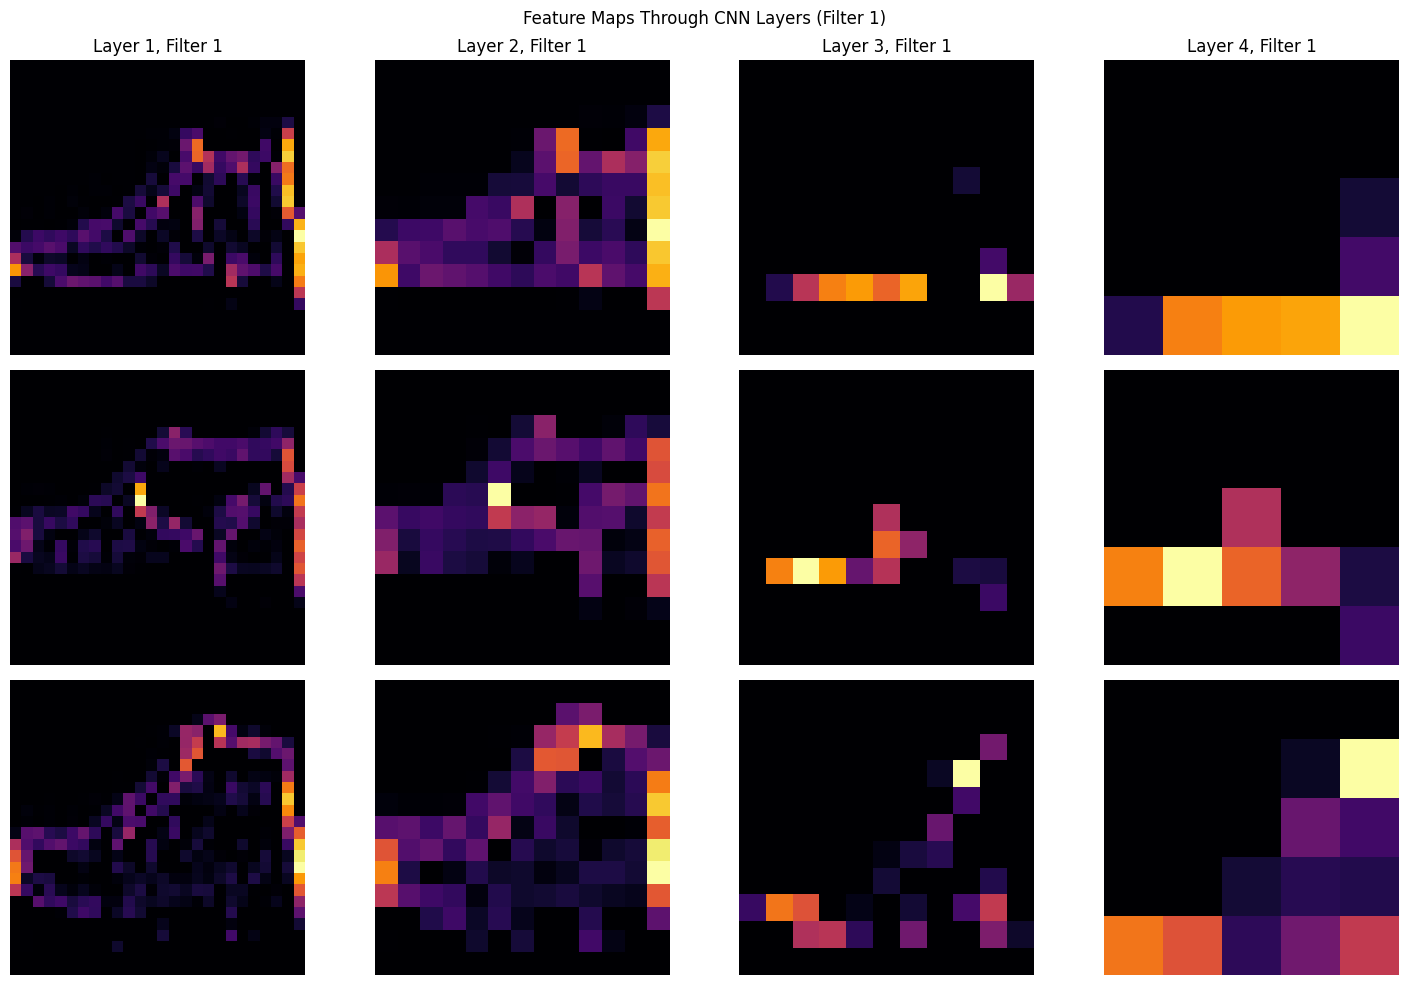

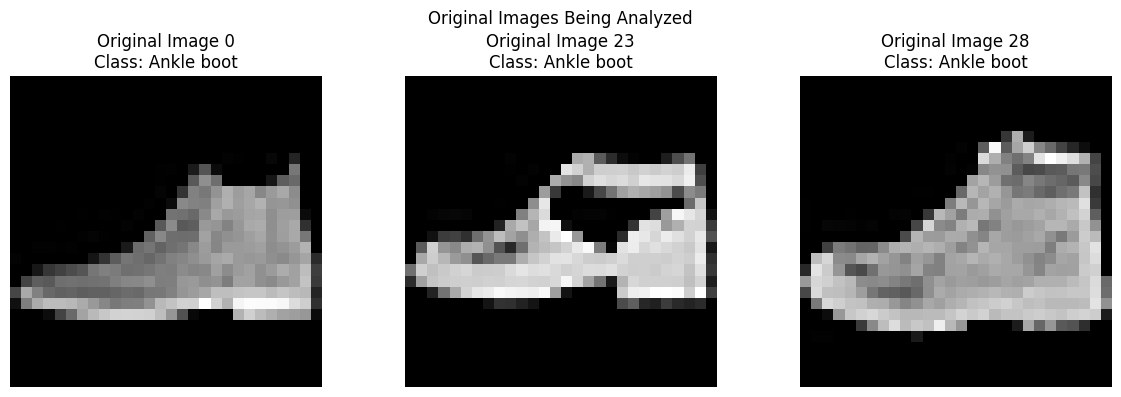

In [14]:
# Create visualization of feature maps
fig, axes = plt.subplots(3, len(layer_outputs), figsize=(15, 10))

for layer_idx in range(len(layer_outputs)):
    # Process first image
    f1 = activation_model.predict(
        test_images[FIRST_IMAGE].reshape(1, 28, 28, 1),
        verbose=False
    )[layer_idx]
    axes[0, layer_idx].imshow(f1[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axes[0, layer_idx].set_title(f'Layer {layer_idx+1}, Filter {CONVOLUTION_NUMBER}')
    axes[0, layer_idx].axis('off')

    # Process second image
    f2 = activation_model.predict(
        test_images[SECOND_IMAGE].reshape(1, 28, 28, 1),
        verbose=False
    )[layer_idx]
    axes[1, layer_idx].imshow(f2[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axes[1, layer_idx].axis('off')

    # Process third image
    f3 = activation_model.predict(
        test_images[THIRD_IMAGE].reshape(1, 28, 28, 1),
        verbose=False
    )[layer_idx]
    axes[2, layer_idx].imshow(f3[0, :, :, CONVOLUTION_NUMBER], cmap='inferno')
    axes[2, layer_idx].axis('off')

plt.suptitle(f'Feature Maps Through CNN Layers (Filter {CONVOLUTION_NUMBER})')
plt.tight_layout()
plt.show()

# Display original images for reference
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
images_to_show = [FIRST_IMAGE, SECOND_IMAGE, THIRD_IMAGE]

for i, img_idx in enumerate(images_to_show):
    axes[i].imshow(test_images[img_idx], cmap='gray')
    axes[i].set_title(f'Original Image {img_idx}\nClass: {class_names[test_labels[img_idx]]}')
    axes[i].axis('off')

plt.suptitle('Original Images Being Analyzed')
plt.tight_layout()
plt.show()

## 8. Manual Convolution Implementation

### Understanding Convolutions from Scratch

To truly understand how convolutions work, let's implement them manually:


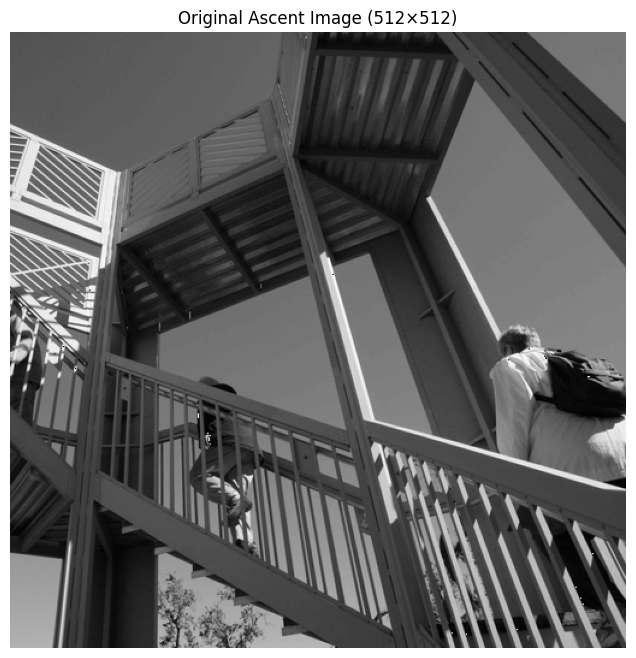

Image shape: (512, 512)
Pixel value range: 0 to 255


In [3]:
# Load the SciPy ascent image for convolution experiments
ascent_image = ascent()

# Visualize the original image
plt.figure(figsize=(8, 8))
plt.imshow(ascent_image, cmap='gray')
plt.title('Original Ascent Image (512×512)')
plt.axis('off')
plt.show()

print(f"Image shape: {ascent_image.shape}")
print(f"Pixel value range: {ascent_image.min()} to {ascent_image.max()}")

### Manual Edge Detection Filter


Edge Detection Filter:
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]
This filter detects areas where center pixel differs from neighbors


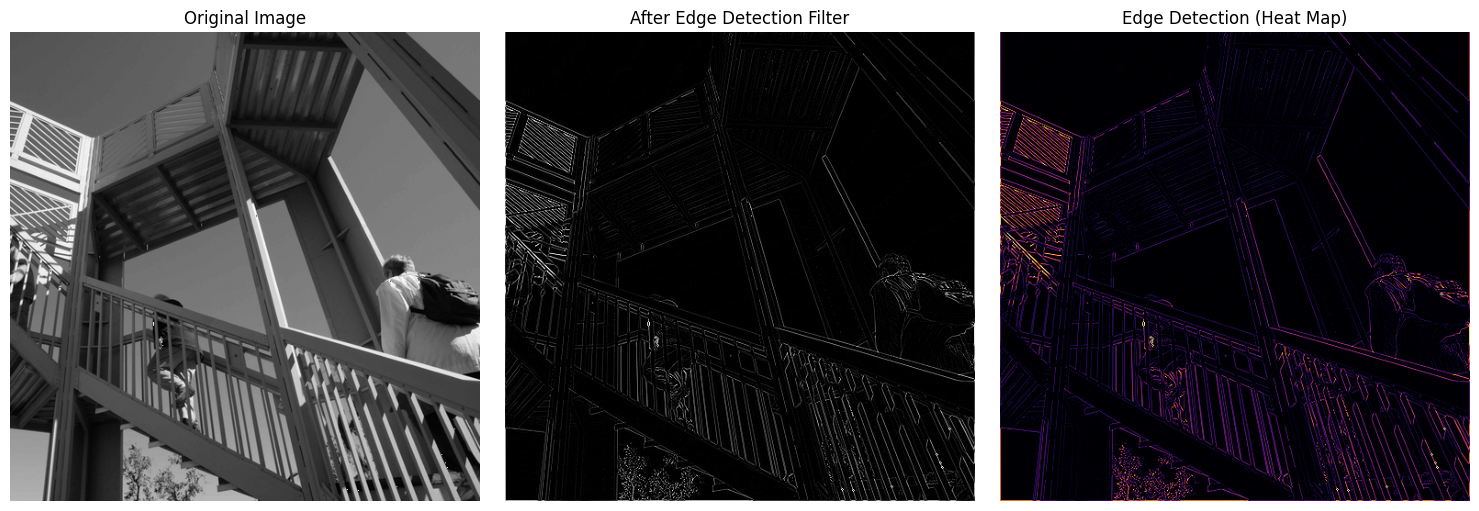

In [14]:
# Create a copy for transformation and convert to float
image_transformed = np.copy(ascent_image).astype(np.float32)
size_x, size_y = image_transformed.shape

# Define edge detection filter
edge_filter = [[0, 1, 0],
               [1, -4, 1],
               [0, 1, 0]]

print("Edge Detection Filter:")
print(np.array(edge_filter))
print("This filter detects areas where center pixel differs from neighbors")

# Apply convolution manually
for x in range(1, size_x-1):  # Leave 1-pixel margin
    for y in range(1, size_y-1):
        convolution = 0.0

        # Apply 3×3 filter
        for i in range(3):
            for j in range(3):
                pixel_value = ascent_image[x-1+i, y-1+j].astype(np.float32)
                filter_value = edge_filter[i][j]
                convolution += pixel_value * filter_value

        # Clamp values to valid range [0, 255]
        convolution = max(0, min(255, convolution))
        image_transformed[x, y] = convolution

# Display result
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(ascent_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_transformed, cmap='gray')
plt.title('After Edge Detection Filter')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_transformed, cmap='inferno')
plt.title('Edge Detection (Heat Map)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Experimenting with Different Filters


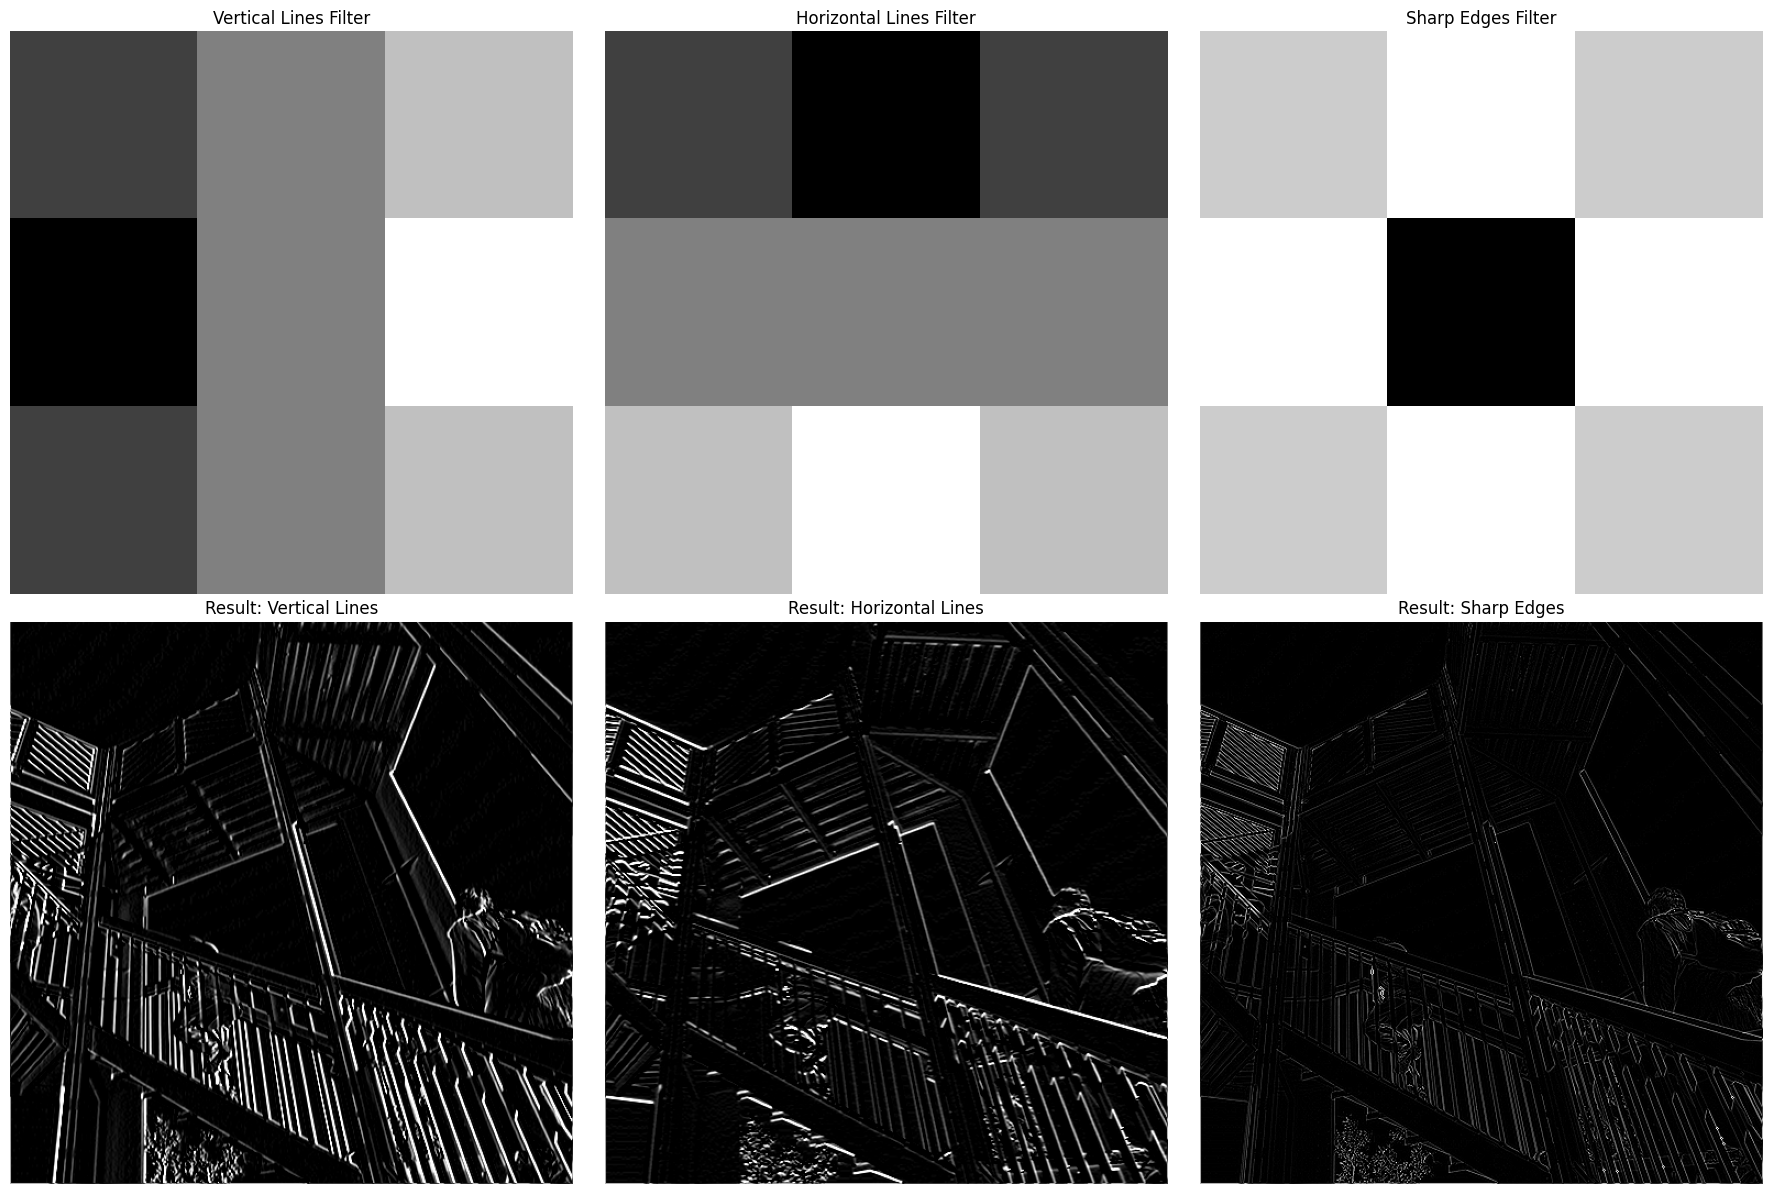

In [15]:
# Define multiple filter types
filters = {
    'Vertical Lines': [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
    'Horizontal Lines': [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
    'Sharp Edges': [[0, 1, 0], [1, -4, 1], [0, 1, 0]]
}

fig, axes = plt.subplots(2, len(filters), figsize=(18, 12))

for col, (filter_name, filter_matrix) in enumerate(filters.items()):
    # Display filter
    axes[0, col].imshow(filter_matrix, cmap='gray')
    axes[0, col].set_title(f'{filter_name} Filter')
    axes[0, col].axis('off')

    # Apply filter to image - convert to float32 to handle negative values
    filtered_image = np.copy(ascent_image).astype(np.float32)

    for x in range(1, size_x-1):
        for y in range(1, size_y-1):
            convolution = 0.0
            for i in range(3):
                for j in range(3):
                    pixel_value = ascent_image[x-1+i, y-1+j].astype(np.float32)
                    convolution += pixel_value * filter_matrix[i][j]

            # Clamp and store
            filtered_image[x, y] = max(0, min(255, convolution))

    # Display result
    axes[1, col].imshow(filtered_image, cmap='gray')
    axes[1, col].set_title(f'Result: {filter_name}')
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

## 9. Manual Max Pooling Implementation

### 2×2 Max Pooling from Scratch


Applying 2×2 Max Pooling...
Original size: (512, 512)
After pooling: (256, 256)
Size reduction: 75.0%


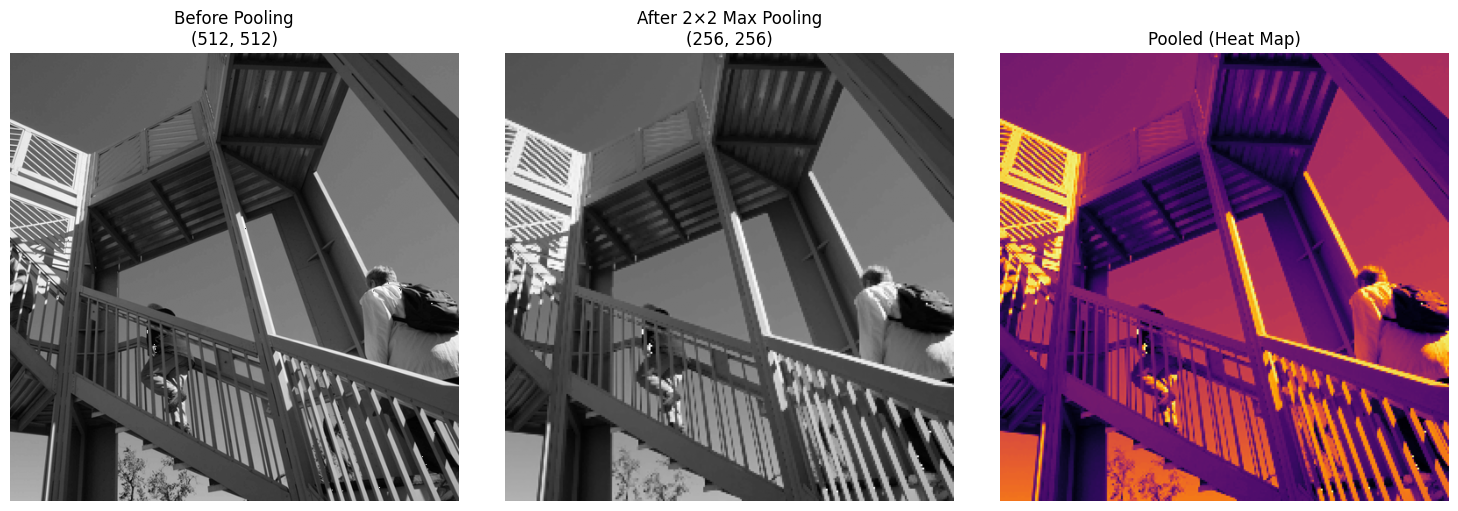

In [6]:
# Apply max pooling to the edge-detected image
print("Applying 2×2 Max Pooling...")

# Calculate new dimensions (half the original)
new_x = size_x // 2
new_y = size_y // 2
pooled_image = np.zeros((new_x, new_y))

# Apply max pooling
for x in range(0, size_x-1, 2):  # Step by 2
    for y in range(0, size_y-1, 2):
        # Extract 2×2 window
        window = image_transformed[x:x+2, y:y+2]
        # Take maximum value
        pooled_image[x//2, y//2] = np.max(window)

print(f"Original size: {image_transformed.shape}")
print(f"After pooling: {pooled_image.shape}")
print(f"Size reduction: {(1 - (pooled_image.size / image_transformed.size)):.1%}")

# Visualize pooling effect
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_transformed, cmap='gray')
plt.title(f'Before Pooling\n{image_transformed.shape}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(pooled_image, cmap='gray')
plt.title(f'After 2×2 Max Pooling\n{pooled_image.shape}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(pooled_image, cmap='inferno')
plt.title('Pooled (Heat Map)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 10. Parameter Analysis and Efficiency

### Understanding Parameter Counts


In [13]:
def count_parameters(model, model_name):
    """Count and display parameters for each layer"""
    print(f"\n=== {model_name} Parameter Analysis ===")
    total_params = 0

    for i, layer in enumerate(model.layers):
        layer_params = layer.count_params()
        total_params += layer_params
        print(f"Layer {i}: {layer.name:15} → {layer_params:,} parameters")

    print(f"Total parameters: {total_params:,}")
    return total_params

# Analyze both models
traditional_params = count_parameters(traditional_model, "Traditional DNN")
cnn_params = count_parameters(cnn_model, "CNN")

print(f"\n=== Parameter Comparison ===")
print(f"Traditional DNN: {traditional_params:,} parameters")
print(f"CNN: {cnn_params:,} parameters")
print(f"Difference: {(cnn_params - traditional_params):,} parameters")
print(f"CNN has {(cnn_params / traditional_params):.1f}x more parameters")


=== Traditional DNN Parameter Analysis ===
Layer 0: flatten_4       → 0 parameters
Layer 1: dense_8         → 100,480 parameters
Layer 2: dense_9         → 1,290 parameters
Total parameters: 101,770

=== CNN Parameter Analysis ===
Layer 0: conv2d_8        → 640 parameters
Layer 1: max_pooling2d_8 → 0 parameters
Layer 2: conv2d_9        → 36,928 parameters
Layer 3: max_pooling2d_9 → 0 parameters
Layer 4: flatten_5       → 0 parameters
Layer 5: dense_10        → 204,928 parameters
Layer 6: dense_11        → 1,290 parameters
Total parameters: 243,786

=== Parameter Comparison ===
Traditional DNN: 101,770 parameters
CNN: 243,786 parameters
Difference: 142,016 parameters
CNN has 2.4x more parameters


## 11. Advanced Experiments and Customization

### Experimenting with Different Architectures


In [8]:
# Create models with different numbers of filters
def create_cnn_variant(filters_1, filters_2, name):
    """Create CNN variant with specified filter counts"""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(filters_1, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(filters_2, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ], name=name)
    return model

# Create different variants
variants = {
    'Small CNN': create_cnn_variant(32, 32, 'small_cnn'),
    'Standard CNN': create_cnn_variant(64, 64, 'standard_cnn'),
    'Large CNN': create_cnn_variant(128, 128, 'large_cnn')
}

# Compare architectures
for name, model in variants.items():
    param_count = model.count_params()
    print(f"{name:12}: {param_count:,} parameters")

Small CNN   : 113,386 parameters
Standard CNN: 243,786 parameters
Large CNN   : 559,882 parameters


### Adding Early Stopping


In [9]:
# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train with validation split and early stopping
print("Training CNN with early stopping...")
cnn_model_with_stopping = create_cnn_variant(64, 64, 'cnn_early_stop')
cnn_model_with_stopping.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_with_stopping = cnn_model_with_stopping.fit(
    training_images, training_labels,
    epochs=20,  # Higher epoch count
    validation_split=0.2,  # Use 20% for validation
    callbacks=[early_stopping],
    verbose=1
)

Training CNN with early stopping...
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8322 - loss: 0.4647 - val_accuracy: 0.8775 - val_loss: 0.3359
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8856 - loss: 0.3075 - val_accuracy: 0.8939 - val_loss: 0.2937
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9039 - loss: 0.2596 - val_accuracy: 0.8967 - val_loss: 0.2876
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9171 - loss: 0.2258 - val_accuracy: 0.8912 - val_loss: 0.3017
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9252 - loss: 0.2002 - val_accuracy: 0.9087 - val_loss: 0.2641
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9342 - loss: 0.1749 - val_accuracy: 0.9083 - val_loss: 0.2589
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9421 - loss: 0.1541 - val_accuracy: 0.9079 - val_loss: 0.2669
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13